In [188]:
import numpy as np
import pandas as pd
import plotly as px
import seaborn as sns
import matplotlib.pyplot as plt

Dataset 1 


In [146]:
df = pd.read_csv("fear_greed_index.csv")

In [147]:
df.shape

(2644, 4)

In [148]:
df.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [149]:
df.isna().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [150]:
df.dtypes

timestamp         int64
value             int64
classification      str
date                str
dtype: object

In [151]:
df['date'] = pd.to_datetime(df['date']).dt.date

In [152]:
df.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [153]:
df['classification'].value_counts()

classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64

In [154]:
df.duplicated().sum()

np.int64(0)

In [155]:
df.drop(columns=['timestamp'],inplace = True)

In [156]:
df.head()

,value,classification,date
0,30,Fear,2018-02-01
1,15,Extreme Fear,2018-02-02
2,40,Fear,2018-02-03
3,24,Extreme Fear,2018-02-04
4,11,Extreme Fear,2018-02-05


Dataset 2

In [157]:
df2 = pd.read_csv("historical_data.csv")

In [158]:
df2.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [159]:
df2.shape

(211224, 16)

In [160]:
df2.isna().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [161]:
df2.dtypes

Account                 str
Coin                    str
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                    str
Timestamp IST           str
Start Position      float64
Direction               str
Closed PnL          float64
Transaction Hash        str
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object

In [162]:
df2.duplicated().sum()

np.int64(0)

In [163]:
df2.columns.tolist()

['Account',
 'Coin',
 'Execution Price',
 'Size Tokens',
 'Size USD',
 'Side',
 'Timestamp IST',
 'Start Position',
 'Direction',
 'Closed PnL',
 'Transaction Hash',
 'Order ID',
 'Crossed',
 'Fee',
 'Trade ID',
 'Timestamp']

In [164]:
df2.rename(columns={
    'Execution Price':'Execution_Price',
    'Size Tokens':'Size_Tokens',
    'Size USD':'Size_USD',
    'Timestamp IST':'Timestamp_IST',
    'Start Position':'Start_Position',
    'Closed PnL':'Closed_Pnl',
    'Transaction Hash':'Transaction_Hash',
    'Order ID':'Order_ID',
    'Trade ID':'Trade_ID',
},inplace=True)


In [165]:
df2.columns.tolist()

['Account',
 'Coin',
 'Execution_Price',
 'Size_Tokens',
 'Size_USD',
 'Side',
 'Timestamp_IST',
 'Start_Position',
 'Direction',
 'Closed_Pnl',
 'Transaction_Hash',
 'Order_ID',
 'Crossed',
 'Fee',
 'Trade_ID',
 'Timestamp']

In [166]:
df2['date'] = pd.to_datetime(df2['Timestamp_IST'], dayfirst=True).dt.date

In [167]:
df2.drop(columns=['Timestamp_IST',],inplace = True)

In [168]:
df2.head()

,Account,Coin,Execution_Price,Size_Tokens,Size_USD,Side,Start_Position,Direction,Closed_Pnl,Transaction_Hash,Order_ID,Crossed,Fee,Trade_ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02


In [169]:
# df2.drop(columns=['Transaction_Hash','Order_ID','Trade_ID','Timestamp'],inplace = True)

In [170]:
# df2.head()

In [172]:
cols = ['Account', 'Coin', 'Side', 'Closed_Pnl', 'Fee', 'Execution_Price', 'Size_USD', 'date']
analysis_df = df2[cols]

Merged Dataset (1&2)

In [173]:
merged = analysis_df.merge(df[['date','value','classification']],on='date',how='left')

In [174]:
merged.shape

(211224, 10)

In [175]:
merged.head()

,Account,Coin,Side,Closed_Pnl,Fee,Execution_Price,Size_USD,date,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,0.0,0.345404,7.9769,7872.16,2024-12-02,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,0.0,0.005600,7.9800,127.68,2024-12-02,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,0.0,0.050431,7.9855,1150.63,2024-12-02,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,0.0,0.050043,7.9874,1142.04,2024-12-02,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,0.0,0.003055,7.9894,69.75,2024-12-02,80.0,Extreme Greed


In [177]:
merged.isna().sum()

Account            0
Coin               0
Side               0
Closed_Pnl         0
Fee                0
Execution_Price    0
Size_USD           0
date               0
value              6
classification     6
dtype: int64

In [179]:
merged['classification'].value_counts()

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

In [182]:
merged.dropna(subset=['classification'], inplace=True)

merged.shape

(211218, 10)

In [181]:
merged.isna().sum()

Account            0
Coin               0
Side               0
Closed_Pnl         0
Fee                0
Execution_Price    0
Size_USD           0
date               0
value              0
classification     0
dtype: int64

In [183]:
pnl_sentiment = merged.groupby('classification').agg(
    total_pnl=('Closed_Pnl', 'sum'),
    avg_pnl=('Closed_Pnl', 'mean'),
    trade_count=('Closed_Pnl', 'count'),
    win_rate=('Closed_Pnl', lambda x: (x > 0).sum() / len(x) * 100)
).reset_index()

print(pnl_sentiment)

  classification     total_pnl    avg_pnl  trade_count   win_rate
0   Extreme Fear  7.391102e+05  34.537862        21400  37.060748
1  Extreme Greed  2.715171e+06  67.892861        39992  46.494299
2           Fear  3.357155e+06  54.290400        61837  42.076750
3          Greed  2.150129e+06  42.743559        50303  38.482794
4        Neutral  1.292921e+06  34.307718        37686  39.699093


In [184]:
side_sentiment = merged.groupby(['classification', 'Side']).agg(
    avg_pnl=('Closed_Pnl', 'mean'),
    total_pnl=('Closed_Pnl', 'sum'),
    count=('Closed_Pnl', 'count')
).reset_index()

print(side_sentiment)

  classification  Side     avg_pnl     total_pnl  count
0   Extreme Fear   BUY   34.114627  3.730434e+05  10935
1   Extreme Fear  SELL   34.980106  3.660668e+05  10465
2  Extreme Greed   BUY   10.498927  1.883508e+05  17940
3  Extreme Greed  SELL  114.584643  2.526821e+06  22052
4           Fear   BUY   63.927104  1.935073e+06  30270
5           Fear  SELL   45.049641  1.422082e+06  31567
6          Greed   BUY   25.002302  6.144566e+05  24576
7          Greed  SELL   59.691091  1.535673e+06  25727
8        Neutral   BUY   29.227429  5.544151e+05  18969
9        Neutral  SELL   39.456408  7.385056e+05  18717


In [185]:
top_traders = merged.groupby('Account').agg(
    total_pnl=('Closed_Pnl', 'sum'),
    avg_pnl=('Closed_Pnl', 'mean'),
    trade_count=('Closed_Pnl', 'count'),
    win_rate=('Closed_Pnl', lambda x: (x > 0).sum() / len(x) * 100)
).sort_values('total_pnl', ascending=False).head(10)

print(top_traders)

                                               total_pnl     avg_pnl  \
Account                                                                
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  2.143383e+06  145.481748   
0x083384f897ee0f19899168e3b1bec365f52a9012  1.600230e+06  419.127768   
0xbaaaf6571ab7d571043ff1e313a9609a10637864  9.401638e+05   44.364091   
0x513b8629fe877bb581bf244e326a047b249c4ff1  8.404226e+05   68.684419   
0xbee1707d6b44d4d52bfe19e41f8a828645437aab  8.360806e+05   20.806305   
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4  6.777471e+05  155.589314   
0x72743ae2822edd658c0c50608fd7c5c501b2afbd  4.293556e+05  270.034947   
0x430f09841d65beb3f27765503d0f850b8bce7713  4.165419e+05  336.735548   
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4  3.790954e+05   38.319560   
0x72c6a4624e1dffa724e6d00d64ceae698af892a0  3.605395e+05  253.187858   

                                            trade_count   win_rate  
Account                                                           

In [186]:
top_coins = merged.groupby('Coin').agg(
    total_pnl=('Closed_Pnl', 'sum'),
    trade_count=('Closed_Pnl', 'count')
).sort_values('total_pnl', ascending=False).head(10)

print(top_coins)

            total_pnl  trade_count
Coin                              
@107     2.783913e+06        29992
HYPE     1.948485e+06        68005
SOL      1.639556e+06        10691
ETH      1.319979e+06        11158
BTC      8.680447e+05        26064
MELANIA  3.903511e+05         4428
ENA      2.173295e+05          990
SUI      1.992688e+05         1979
ZRO      1.837778e+05         1239
DOGE     1.475432e+05          826


In [187]:
merged['month'] = pd.to_datetime(merged['date']).dt.to_period('M')

monthly = merged.groupby('month').agg(
    total_pnl=('Closed_Pnl', 'sum'),
    avg_fg=('value', 'mean'),
    trade_count=('Closed_Pnl', 'count')
).reset_index()

print(monthly)

      month     total_pnl     avg_fg  trade_count
0   2023-05  0.000000e+00  63.000000            3
1   2023-12  2.016007e+03  70.275660          341
2   2024-01 -1.308594e+04  62.305909         2200
3   2024-02  4.986267e+04  69.049307         2596
4   2024-03  1.249827e+05  81.465549         1611
5   2024-04  8.038588e+03  73.167645         1193
6   2024-05  2.933104e+04  71.256107         1269
7   2024-06  1.029840e+05  68.836763         2187
8   2024-07  1.385624e+05  66.018606         2526
9   2024-08 -1.068172e+05  34.896989         1262
10  2024-09  4.823575e+04  47.900000          510
11  2024-10  4.379193e+04  64.678322          715
12  2024-11  1.334300e+05  83.121903         6538
13  2024-12  3.005071e+06  77.183376        29884
14  2025-01  7.677459e+05  72.497452        19817
15  2025-02  2.396979e+06  44.748289        44130
16  2025-03  2.153251e+06  31.156678        40848
17  2025-04  1.315571e+06  42.564288        52358
18  2025-05  5.453683e+04  53.000000         1230


C:\Users\thaku\AppData\Local\Temp\ipykernel_23956\1784132376.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pnl_sentiment, x='classification', y='avg_pnl', palette='coolwarm')


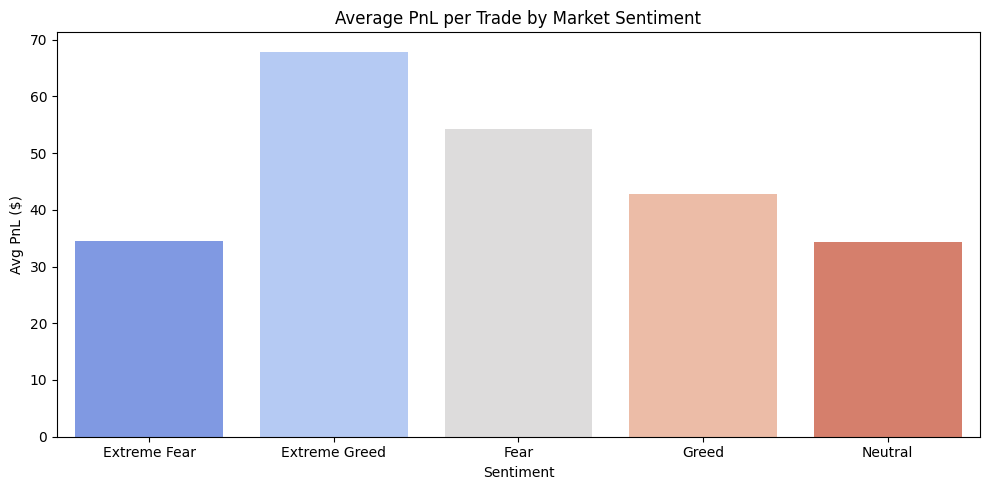

In [192]:
plt.figure(figsize=(10, 5))
sns.barplot(data=pnl_sentiment, x='classification', y='avg_pnl', palette='coolwarm')
plt.title('Average PnL per Trade by Market Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Avg PnL ($)')
plt.tight_layout()
plt.show()

C:\Users\thaku\AppData\Local\Temp\ipykernel_23956\1813853543.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pnl_sentiment, x='classification', y='win_rate', palette='coolwarm')


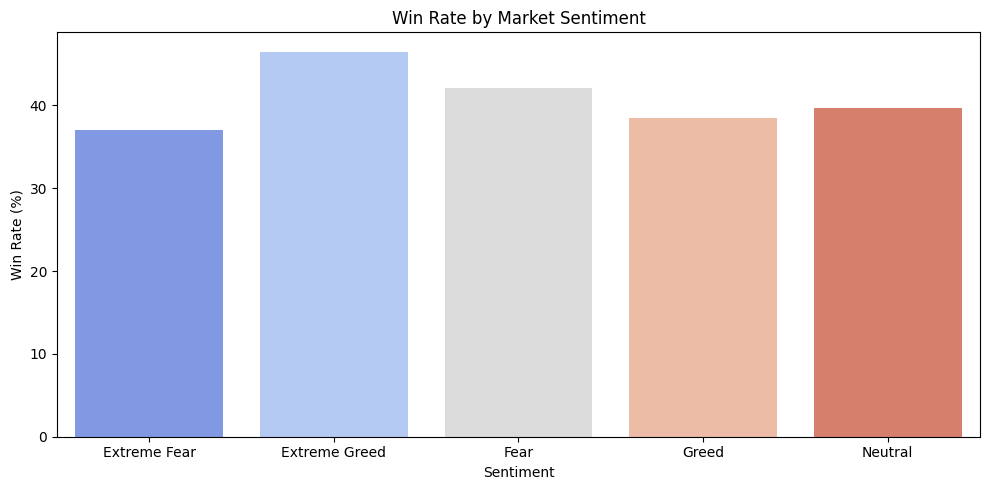

In [193]:
plt.figure(figsize=(10, 5))
sns.barplot(data=pnl_sentiment, x='classification', y='win_rate', palette='coolwarm')
plt.title('Win Rate by Market Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Win Rate (%)')
plt.tight_layout()
plt.show()

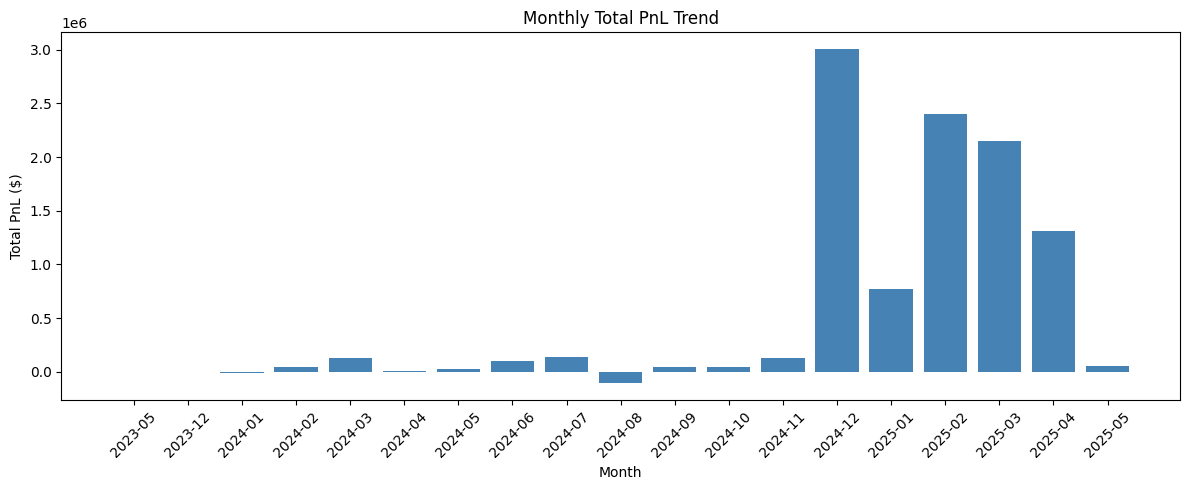

In [195]:
plt.figure(figsize=(12, 5))
plt.bar(monthly['month'].astype(str), monthly['total_pnl'], color='steelblue')
plt.title('Monthly Total PnL Trend')
plt.xlabel('Month')
plt.ylabel('Total PnL ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\thaku\AppData\Local\Temp\ipykernel_23956\3160060576.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top8, x='total_pnl', y='Coin', palette='viridis')


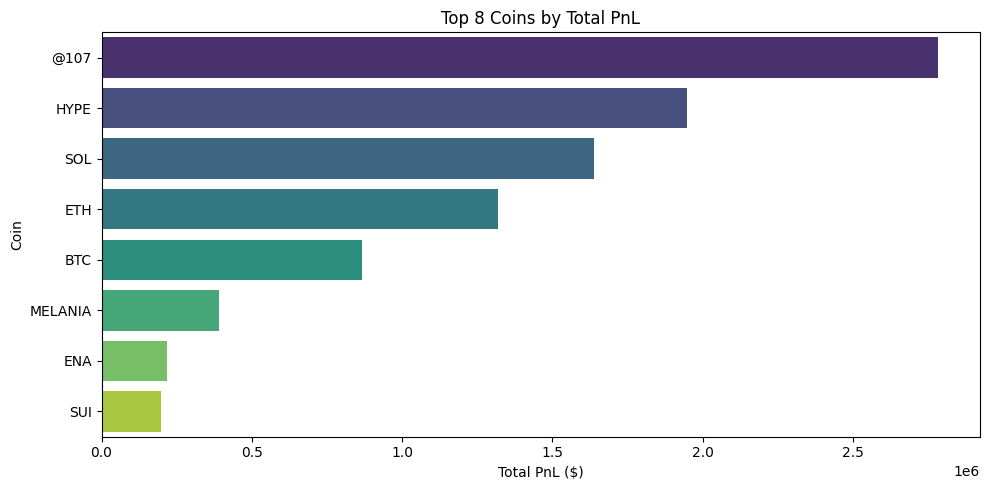

In [197]:
top8 = top_coins.head(8).reset_index()
plt.figure(figsize=(10, 5))
sns.barplot(data=top8, x='total_pnl', y='Coin', palette='viridis')
plt.title('Top 8 Coins by Total PnL')
plt.xlabel('Total PnL ($)')
plt.ylabel('Coin')
plt.tight_layout()
plt.show()

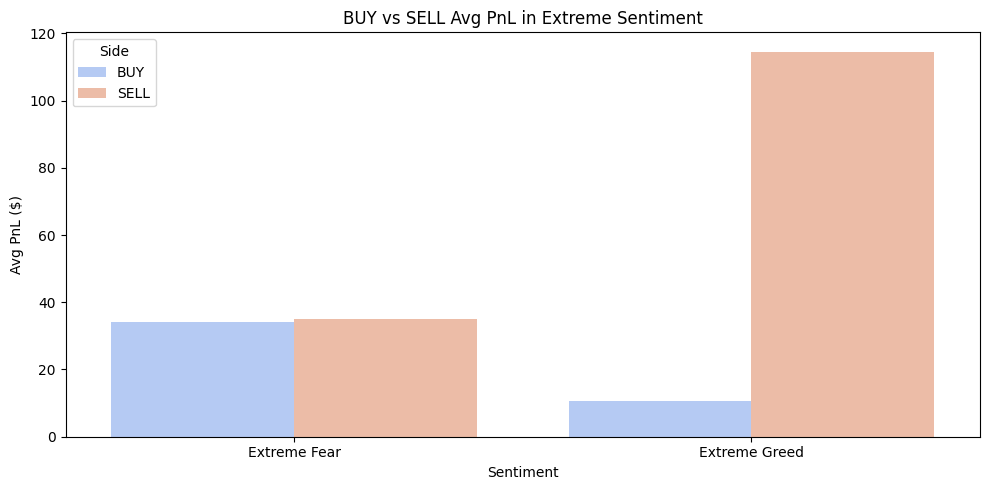

In [198]:
extreme = side_sentiment[side_sentiment['classification'].isin(['Extreme Fear', 'Extreme Greed'])]
plt.figure(figsize=(10, 5))
sns.barplot(data=extreme, x='classification', y='avg_pnl', hue='Side', palette='coolwarm')
plt.title('BUY vs SELL Avg PnL in Extreme Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Avg PnL ($)')
plt.tight_layout()
plt.show()

C:\Users\thaku\AppData\Local\Temp\ipykernel_23956\2705209734.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x='label', y='total_pnl', palette='viridis')


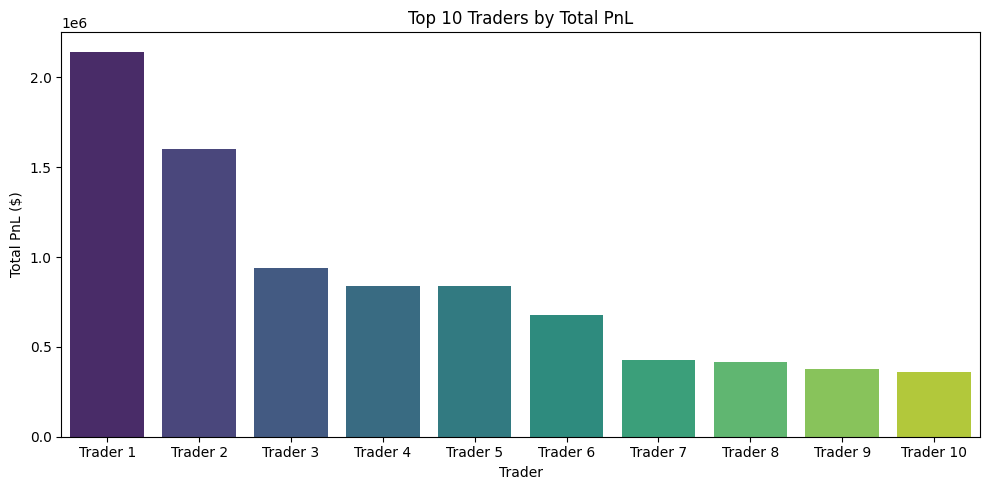

In [199]:
top10 = top_traders.reset_index()
top10['label'] = ['Trader ' + str(i+1) for i in range(len(top10))]
plt.figure(figsize=(10, 5))
sns.barplot(data=top10, x='label', y='total_pnl', palette='viridis')
plt.title('Top 10 Traders by Total PnL')
plt.xlabel('Trader')
plt.ylabel('Total PnL ($)')
plt.tight_layout()
plt.show()